In [21]:
# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import warnings
import gc
import os
import time

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

# Reproducibility
SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

print("✅ All libraries imported successfully")
print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")

✅ All libraries imported successfully
XGBoost  : 3.1.2
LightGBM : 4.6.0


In [23]:
# ============================================================================
# CELL 2: LOAD ALL DATASETS
# ============================================================================

# --- Competition data ---
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# --- Original Telco Customer Churn data ---
# The original dataset from: blastchar/telco-customer-churn
#original = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("="*60)
print("DATASET SHAPES")
print("="*60)
print(f"Competition Train : {train.shape}")
print(f"Competition Test  : {test.shape}")
#print(f"Original Dataset  : {original.shape}")
print(f"Sample Submission : {sample_sub.shape}")
print("="*60)

DATASET SHAPES
Competition Train : (594194, 21)
Competition Test  : (254655, 20)
Sample Submission : (254655, 2)


In [24]:
# ============================================================================
# CELL 3: QUICK EDA
# ============================================================================

print("="*60)
print("TRAIN INFO")
print("="*60)
print(train.info())
print("\n")
print("="*60)
print("FIRST 5 ROWS")
print("="*60)
display(train.head())

print("\n")
print("="*60)
print("TARGET DISTRIBUTION (Competition Train)")
print("="*60)
print(train['Churn'].value_counts())
print(train['Churn'].value_counts(normalize=True))

print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)
print(f"Train nulls : {train.isnull().sum().sum()}")
print(f"Test nulls  : {test.isnull().sum().sum()}")
print(f"Orig nulls  : {original.isnull().sum().sum()}")

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  Paperless

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes




TARGET DISTRIBUTION (Competition Train)
Churn
No     460377
Yes    133817
Name: count, dtype: int64
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


MISSING VALUES
Train nulls : 0
Test nulls  : 0
Orig nulls  : 0


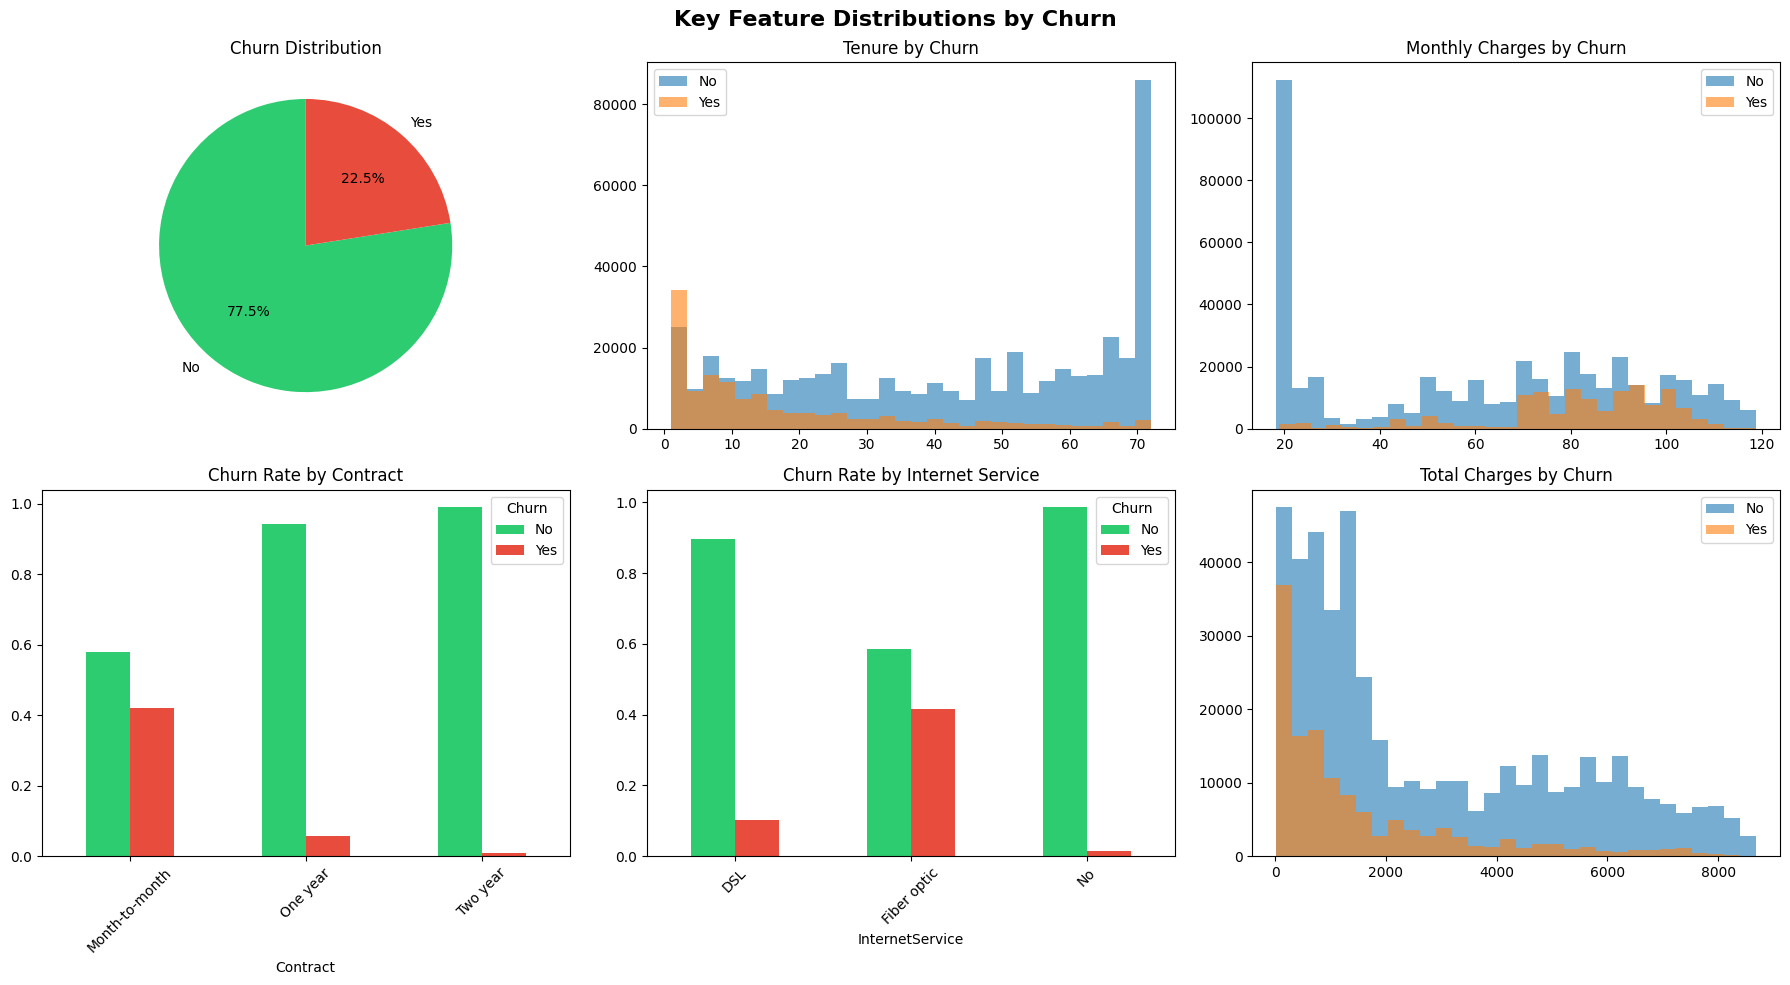

In [25]:
# ============================================================================
# CELL 4: EDA VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Feature Distributions by Churn', fontsize=16, fontweight='bold')

# 1. Churn distribution
churn_counts = train['Churn'].value_counts()
axes[0, 0].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 0].set_title('Churn Distribution')

# 2. Tenure distribution
for label in train['Churn'].unique():
    subset = train[train['Churn'] == label]
    axes[0, 1].hist(subset['tenure'], bins=30, alpha=0.6, label=str(label))
axes[0, 1].set_title('Tenure by Churn')
axes[0, 1].legend()

# 3. Monthly Charges
for label in train['Churn'].unique():
    subset = train[train['Churn'] == label]
    axes[0, 2].hist(subset['MonthlyCharges'], bins=30, alpha=0.6, label=str(label))
axes[0, 2].set_title('Monthly Charges by Churn')
axes[0, 2].legend()

# 4. Contract type
ct = pd.crosstab(train['Contract'], train['Churn'], normalize='index')
ct.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Churn Rate by Contract')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Internet Service
ct2 = pd.crosstab(train['InternetService'], train['Churn'], normalize='index')
ct2.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Churn Rate by Internet Service')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Total Charges
for label in train['Churn'].unique():
    subset = train[train['Churn'] == label]
    axes[1, 2].hist(subset['TotalCharges'], bins=30, alpha=0.6, label=str(label))
axes[1, 2].set_title('Total Charges by Churn')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [27]:
# ============================================================================
# CELL 6: FEATURE ENGINEERING
# ============================================================================

def feature_engineering(df):
    """
    Grandmaster-level feature engineering for Telco Churn.
    Returns df with new features + all categoricals encoded.
    """
    df = df.copy()

    # ------------------------------------------------------------------
    # 1. ENCODE TARGET  (Yes/No → 1/0)  — only if present & object
    # ------------------------------------------------------------------
    if 'Churn' in df.columns and df['Churn'].dtype == 'object':
        df['Churn'] = (df['Churn'] == 'Yes').astype(int)

    # ------------------------------------------------------------------
    # 2. NUMERIC INTERACTIONS
    # ------------------------------------------------------------------
    df['tenure_MonthlyCharges']   = df['tenure'] * df['MonthlyCharges']
    df['tenure_TotalCharges']     = df['tenure'] * df['TotalCharges']
    df['Monthly_Total_ratio']     = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
    df['Avg_Monthly_byTenure']    = df['TotalCharges'] / (df['tenure'] + 1)
    df['Charge_Diff']             = df['MonthlyCharges'] - (df['TotalCharges'] / (df['tenure'] + 1))
    df['tenure_squared']          = df['tenure'] ** 2
    df['MonthlyCharges_squared']  = df['MonthlyCharges'] ** 2

    # ------------------------------------------------------------------
    # 3. TENURE BINS  (business-logic driven)
    # ------------------------------------------------------------------
    df['tenure_bin'] = pd.cut(
        df['tenure'],
        bins=[-1, 6, 12, 24, 48, 72, 200],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

    df['is_new_customer']   = (df['tenure'] <= 6).astype(int)
    df['is_loyal_customer'] = (df['tenure'] >= 48).astype(int)

    # ------------------------------------------------------------------
    # 4. SERVICE COUNTS
    # ------------------------------------------------------------------
    service_cols = [
        'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    for col in service_cols:
        if col in df.columns and df[col].dtype == 'object':
            df[col + '_flag'] = (df[col].isin(['Yes', 'Fiber optic', 'DSL'])).astype(int)

    flag_cols = [c for c in df.columns if c.endswith('_flag')]
    df['total_services'] = df[flag_cols].sum(axis=1)
    # Drop intermediate flags
    df.drop(columns=flag_cols, inplace=True)

    # ------------------------------------------------------------------
    # 5. STREAMING BUNDLE
    # ------------------------------------------------------------------
    df['has_streaming_bundle'] = (
        (df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')
    ).astype(int)

    # ------------------------------------------------------------------
    # 6. SECURITY BUNDLE
    # ------------------------------------------------------------------
    df['has_security_bundle'] = (
        (df['OnlineSecurity'] == 'Yes') & (df['DeviceProtection'] == 'Yes')
    ).astype(int)

    # ------------------------------------------------------------------
    # 7. LABEL-ENCODE ALL REMAINING OBJECT COLUMNS
    # ------------------------------------------------------------------
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    return df, label_encoders, cat_cols


# --- Apply to combined train ---
train_fe, le_dict, cat_columns = feature_engineering(train_combined)

# --- Apply to test ---
test_fe, _, _ = feature_engineering(test)

print("✅ Feature engineering complete")
print(f"Train features: {train_fe.shape}")
print(f"Test  features: {test_fe.shape}")

NameError: name 'train_combined' is not defined